# 분류 모델 평가 실습

이 파일은 분류 모델의 평가 지표를 직접 확인하는 실습용 파일이다.

실습 구성
1. 이진 분류 평가 - 유방암 진단
2. 다중 분류 평가 - 아이리스

실습 목표
1. 분류 문제에서 train/test 분리 후 모델을 학습할 수 있다.
2. confusion matrix를 통해 어떤 예측이 맞고 틀렸는지 해석할 수 있다.
3. accuracy, precision, recall, f1-score의 의미를 결과와 함께 해석할 수 있다.
4. 이진 분류에서는 ROC Curve와 AUC를 확인할 수 있다.
5. 다중 분류에서는 classification report와 macro 평균의 의미를 확인할 수 있다.

진행 가이드
1. 각 문제의 요구사항을 먼저 읽는다.
2. 코드 셀은 직접 작성한다.
3. 출력 결과를 보고 해석 질문까지 답해본다.
4. 필요하면 셀을 추가해도 된다.


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)


## 1. 이진 분류 평가 - 유방암 진단

실습 목적
- 악성(malignant) / 양성(benign) 두 클래스를 구분하는 이진 분류 문제를 다룬다.
- 정확도만 보는 것이 아니라 정밀도, 재현율, F1-score, ROC-AUC까지 함께 확인한다.
- 특히 의료 진단과 같이 놓치면 안 되는 문제에서 재현율이 왜 중요한지 생각해본다.

요구사항
1. `load_breast_cancer()`로 데이터를 불러온다.
2. 입력 데이터와 타깃 데이터의 shape를 확인한다.
3. DataFrame으로 변환하여 앞부분을 확인한다.
4. `train_test_split()`으로 학습/테스트 데이터를 분리한다.
   - `test_size=0.2`
   - `random_state=42`
   - `stratify=target`
5. `LogisticRegression` 모델을 학습한다.
6. 테스트 데이터 예측값과 양성 확률값을 구한다.
7. 아래 평가를 수행한다.
   - confusion matrix
   - accuracy
   - precision
   - recall
   - f1-score
   - classification report
8. ROC Curve를 그리고 AUC를 계산한다.

해석 질문
1. confusion matrix에서 FP와 FN은 각각 무엇을 의미하는가?
fp: 양성이 나온 음성 값, 음성이 나온 양성값
2. 의료 진단 문제에서 precision과 recall 중 어떤 값을 더 중요하게 볼 수 있는가?
recall
3. AUC 값이 높다는 것은 무엇을 의미하는가?
구분을 정확하게 한다.

In [36]:
# 1) 데이터 로드
from sklearn.datasets import load_breast_cancer
breast_cancer = load_breast_cancer()
breast_cancer.data

array([[ 17.99 ,  10.38 , 122.8  , ...,   0.265,   0.46 ,   0.119],
       [ 20.57 ,  17.77 , 132.9  , ...,   0.186,   0.275,   0.089],
       [ 19.69 ,  21.25 , 130.   , ...,   0.243,   0.361,   0.088],
       ...,
       [ 16.6  ,  28.08 , 108.3  , ...,   0.142,   0.222,   0.078],
       [ 20.6  ,  29.33 , 140.1  , ...,   0.265,   0.409,   0.124],
       [  7.76 ,  24.54 ,  47.92 , ...,   0.   ,   0.287,   0.07 ]],
      shape=(569, 30))

In [37]:
# 2) 데이터프레임으로 확인
X_df = pd.DataFrame(breast_cancer.data)
Y_df = pd.DataFrame(breast_cancer.target)
display(X_df)
display(Y_df)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


,0
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [38]:
# 3) train / test 분리
X_train, X_test, Y_train, Y_test = train_test_split(X_df,Y_df,test_size=0.2,random_state=42,stratify=Y_df)

print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(455, 30) (455, 1)
(114, 30) (114, 1)


In [39]:
# 4) 모델 학습
lr_bc = LogisticRegression()

lr_bc.fit(X_train,Y_train)

c:\Users\Playdata\AppData\Local\miniforge3\envs\ai_basic_env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Playdata\AppData\Local\miniforge3\envs\ai_basic_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [71]:
# 5) 예측값 / 예측확률 구하기
Y_train_pred = lr_bc.predict(X_train)
Y_test_pred = lr_bc.predict(X_test)

Y_pred_proba = lr_bc.predict_proba(X_test)
print(Y_pred_proba)

print(lr_bc.score(X_train,Y_train))
print(lr_bc.score(X_test,Y_test))

[[1.    0.   ]
 [0.    1.   ]
 [0.793 0.207]
 [0.574 0.426]
 [1.    0.   ]
 [0.022 0.978]
 [0.002 0.998]
 [1.    0.   ]
 [1.    0.   ]
 [1.    0.   ]
 [0.002 0.998]
 [0.99  0.01 ]
 [0.004 0.996]
 [1.    0.   ]
 [0.999 0.001]
 [0.06  0.94 ]
 [0.454 0.546]
 [0.013 0.987]
 [0.007 0.993]
 [0.07  0.93 ]
 [0.992 0.008]
 [0.997 0.003]
 [0.011 0.989]
 [0.002 0.998]
 [0.112 0.888]
 [0.082 0.918]
 [1.    0.   ]
 [0.008 0.992]
 [0.005 0.995]
 [0.117 0.883]
 [0.042 0.958]
 [0.001 0.999]
 [0.03  0.97 ]
 [0.002 0.998]
 [1.    0.   ]
 [0.647 0.353]
 [0.003 0.997]
 [0.002 0.998]
 [0.066 0.934]
 [1.    0.   ]
 [0.012 0.988]
 [0.002 0.998]
 [0.053 0.947]
 [1.    0.   ]
 [0.996 0.004]
 [0.459 0.541]
 [0.001 0.999]
 [0.001 0.999]
 [0.004 0.996]
 [0.999 0.001]
 [0.004 0.996]
 [0.231 0.769]
 [0.    1.   ]
 [0.208 0.792]
 [0.009 0.991]
 [0.002 0.998]
 [0.    1.   ]
 [1.    0.   ]
 [1.    0.   ]
 [0.005 0.995]
 [0.04  0.96 ]
 [0.    1.   ]
 [0.001 0.999]
 [0.064 0.936]
 [1.    0.   ]
 [0.195 0.805]
 [0.157 0.

In [41]:
# 6) confusion matrix 확인
confusion_matrix(Y_test,Y_test_pred)

array([[38,  4],
       [ 1, 71]])

In [42]:
# 7) 평가지표 계산
print(accuracy_score(Y_test,Y_test_pred))
print(precision_score(Y_test_pred,Y_test))
print(recall_score(Y_test_pred,Y_test))
print(f1_score(Y_test_pred,Y_test))


0.956140350877193
0.9861111111111112
0.9466666666666667
0.9659863945578231


In [43]:
# 8) classification report 출력
print(classification_report(Y_test,Y_test_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



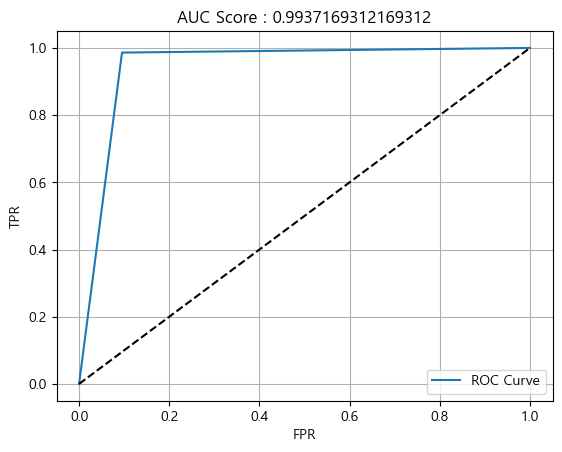

In [72]:
# 9) ROC Curve 시각화 및 AUC 계산
fpr,tpr,theresholds = roc_curve(Y_test,Y_test_pred)

plt.plot(fpr,tpr,label = 'ROC Curve')
plt.plot([0,1],[0,1],'k--')     # (0,0), (1,1)의 직선

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid()
plt.title(f'AUC Score : {roc_auc_score(Y_test,Y_pred_proba[:,1])}')
plt.show()

## 2. 다중 분류 평가 - 아이리스

실습 목적
- setosa, versicolor, virginica 세 품종을 구분하는 다중 분류 문제를 다룬다.
- 다중 분류에서는 클래스가 여러 개이므로 confusion matrix를 표 형태로 해석하는 연습이 중요하다.
- classification report에서 클래스별 precision, recall, f1-score를 비교해본다.

요구사항
1. `load_iris()`로 데이터를 불러온다.
2. 입력 데이터와 타깃 데이터의 shape를 확인한다.
3. `train_test_split()`으로 학습/테스트 데이터를 분리한다.
   - `test_size=0.2`
   - `random_state=42`
   - `stratify=y`
4. `LogisticRegression` 모델을 학습한다.
5. 테스트 데이터 예측값을 구한다.
6. confusion matrix를 출력하고 DataFrame 형태로 보기 좋게 정리한다.
7. classification report를 출력한다.
8. accuracy, precision, recall, f1-score를 `average='macro'`로 계산한다.

해석 질문
1. 어떤 클래스에서 오분류가 발생했는가?
versicolor와 virginica 사이

2. macro average를 사용하는 이유는 무엇인가?
모든 클래스에 동일한 가중치를 부여하여 평균을 내는 방식, 모든 클래스가 골고루 있어서

3. 이진 분류와 달리 다중 분류 평가에서 주의할 점은 무엇인가?
이진 분류에서는 하나의 Precision/Recall 값만 나오지만, 다중 분류에서는 클래스별로 지표가 각각 계산됩니다. 따라서 전체 성능을 요약할 때 macro, micro, weighted 중 어떤 평균 방식을 쓸지 결정해야 합니다

In [57]:
# 1) 데이터 로드
from sklearn.datasets import load_iris
iris = load_iris()

In [58]:
# 2) train / test 분리
x_train, x_test, y_train, y_test = train_test_split(iris.data,iris.target,test_size=0.2,random_state=42,stratify=iris.target)
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(120, 4) (120,)
(30, 4) (30,)


In [ ]:
# 3) 모델 학습
lr_iris = LogisticRegression()
lr_iris.fit(x_train,y_train)

[0 2 1 0 1] [0 1 1 0 1]
[0 2 1 1 0] [0 2 1 1 0]


In [62]:
# 4) 예측값 구하기
y_train_pred = lr_iris.predict(x_train)
y_test_pred = lr_iris.predict(x_test)


print(y_train[:5],y_train_pred[:5])
print(y_test[:5],y_test_pred[:5])

[0 2 1 0 1] [0 1 1 0 1]
[0 2 1 1 0] [0 2 1 1 0]


In [63]:
# 5) confusion matrix 출력
print(confusion_matrix(y_test,y_test_pred))

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [65]:
# 6) confusion matrix를 DataFrame으로 정리
cm_df = pd.DataFrame(confusion_matrix(y_test,y_test_pred))
display(cm_df)

,0,1,2
0,10,0,0
1,0,9,1
2,0,0,10


In [66]:
# 7) classification report 출력
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [67]:
# 8) macro 평균 기준 평가지표 계산
print(f1_score(y_test,y_test_pred,average='macro'))

0.9665831244778612


## 체크

1. 이진 분류에서 `predict()`와 `predict_proba()`를 구분해서 사용했는가?
2. ROC Curve의 x축이 FPR, y축이 TPR임을 확인했는가?
3. 다중 분류에서 precision, recall, f1-score 계산 시 `average` 옵션을 올바르게 사용했는가?
4. 결과 숫자만 출력하지 말고, 어떤 의미인지 해석까지 해보았는가?